# Classical Statistical Inference: Part 1a

## Table of Content:

- I. [Basic probability concepts](#I)    
    * I.1 [Probability Axioms](Basic-statistics_01_Expanded.ipynb)
    * I.2 [What is a random variable ?](#I.2-What-is-a-random-variable-?)
    * I.3 [What is a conditional probability $p(A|B)p(A | B)$ and Bayes theorem ?](#I.3-What-is-a-conditional-probability-$p(A-|-B)$-and-Bayes-theorem?)
    * I.4 [What is a probability density function ?](Basic-statistics_01_Part1b.ipynb/#pdf)
    * I.4b [Bivariate PDF](Basic-statistics_01_Part1b.ipynb/#bivariate)
    * I.5 [What is a cumulative distribution function ?](Basic-statistics_01_Part1b.ipynb/#I.5-What-is-a-cumulative-distribution-function-?)
    * I.6 [Working with pdf and CDF](Basic-statistics_02.ipynb)


- [Descriptive statistics](#Intermezo:-Descriptive-statistics)
    * To review the **properties of probability distribution functions** (mean, standard deviation, variance, skewness, ...), go to the notebook [Descriptive_statistics_01.ipynb](Descriptive_statistics_01.ipynb).    
    * To **better understand visually the link between PDF and CDF**, and do an interactive tour of the characteristics and properties of **common distributions** encountered in science, then, run the Notebook [Descriptive_statistics_02.ipynb](Descriptive_statistics_02.ipynb). 

- X. [References and supplementary material](#X)

In [2]:
# Modules to be used in this notebook
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
%matplotlib inline

## 0. Why some statistics ? 

With this lecture, we aim to give you tools to manipulate data (from observations or from simulations). Data, even when being the outcome of some deterministic process, contain a stochastic component, for example due to the observational device. This means that in essence, data are what statisticians call a **random variable**. This is why, when you report measurements you also need to report some uncertainties. These uncertainty calculation look often to student like some kind of black magic. This also means that they are sometimes not adequately used or reported. We'll clarify in the coming lectures, how to make those calculations using python tools. 

This is a necessary step to enter into the field of machine learning. If you look on Wikipedia at the page dedicated to [Machine learning](https://en.wikipedia.org/wiki/Machine_learning), you'll find the following definition: "Machine learning is the study of computer algorithms that improve automatically through experience. Machine learning algorithms build a mathematical model based on sample data, known as "training data", in order to make predictions or decisions without being explicitly programmed to do so." This is not the result of black magic, but of well understood statistics and probability. 

## I Basic (probability) concepts:  <a class="anchor" id="I"></a>

This section aims at reminding us some definitions and notations, so everybody is on the same page. Illustration with python will also be provided. 

In probability theory, we define the following:
- the set of all possible outcomes of an experiment is generally called **sample space** and denoted, $\Omega$. 
- Points in $\Omega$, are called **realisations** $\omega$. In other words each of your *data point* is a realisation (but there may exist other  realisations that are not in your data). 
- An **Event** is a subset of $\Omega$ (i.e. a subsample of the $\omega$). In other words your *data set* is an event.  
- $p(A)$ is the **probability** of an event A. ($p(A)$ can also refer to a probability that a value of $x$ falls in a d$x$ wide interval around $x$. )

> The *frequentist (classical) interpretation of statistics*: You make a measurement, you repeat it an infinite number of times, and build a histogram. This histogram gives the relative frequency of getting a measurement compared to another. This relative frequency is what we call a probability. The whole possible outcomes of an experiment is called sample space $\Omega$. An event is a subsample of $\omega$ / is an ensemble of realisations (your data set).

**Example**: We measure the magnitude $m$ of a variable star. Then $\Omega = {\rm I\!R}$ (or some plausible range such as $]-30, 40 [ $, but this makes little difference in practice and $\Omega$ can in general be larger than needed). $\omega$ is a value in $\Omega$. While an event is the ensemble of magnitude measurements  that are e.g. such that $m_i > 15$ and $m_i <=15.5$, hence this *event* is A = ]15, 15.5]. Note that an event *can* also be a single point (i.e. A = [17.]). 

If you need some refresh on basic probability concepts, move to the [expanded version](Basic-statistics_01_Expanded.ipynb) of this Notebook. 

### I.1 Probability axioms

Check the [expanded version](Basic-statistics_01_Expanded.ipynb) of this Notebook to refresh your mind about the axioms behind the probability theory. 

### I.2 What is a random variable ?

Definition (informal): 

> A random variable is a variable whose value results from the measurement of a quantity that is subject to random variations. 

**Example:** You roll a dice. You can then define $X(\omega)$ be the *number of times you draw an even number* in a sequence $\omega$. Imagine you have rolled your dice 10 times, and get  $\omega = {1, {\bf 2, 4, 2}, 5, {\bf 4, 6}, 3, 3, 1 }$. Then $X(\omega) = 5$ is the value taken by your *random variable* X. 

Note that you can have either *continuous* or *discrete* random variables. If they form a countable set, they are discrete. They are continuous otherwise. 

**Warning**, a random variable is *NOT* like typical mathematical variables as it can take *different values* (each with an associated probability). In litterature, you will generaly find random variables written with *CAPITAL* letters, and their particular *realization* with *lowercase*. A realisation of a random variable is also called "random variate". 

**Random variable with numpy**

In numpy there is a sub-module called random that contains many functions that involve random selection. In particular there is a function `choice` that allows you to make a choice at random. It picks one item at random from an array, and it is equally likely to pick any of the items. The function call is `np.random.choice(array_name)`, where `array_name` is the name of the array from which to make the choice.

In [3]:
# Let's build a small array with classification of objects on a CCD: 
class_phot = np.array(['star', 'galaxy', 'galaxy', 'star', 'star'])
np.random.choice(class_phot)

'star'

If you re-rerun the above cell multiple times, you will see that the output changes, because the output is taken at random. If you provide a second argument (`size = n`), it will repeat the process $n$ number of times. In practice, this `method` allows you to *generate a random sample* from a 1-D array. You can add a third argument that specifies if you allow replacements or not as the output: i.e. `replace=False` means that the value stored at a given index of the array will only appear once in the output. 

In [4]:
np.random.choice(class_phot, size=3)    

array(['star', 'star', 'galaxy'], dtype='<U6')

In [5]:
# Use e.g. np.arange(5) and size=5 to compare the behaviour with replace=True / replace = False
an_array_of_float = np.arange(5)
np.random.choice(an_array_of_float, size=5, replace=True)

array([2, 4, 1, 3, 0])

In [6]:
np.random.choice(an_array_of_float, size=5, replace=False)

array([0, 2, 4, 3, 1])

In [7]:
#Try out with an array size > size of the random sample 
np.random.choice(an_array_of_float, size=6, replace=False)

ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
np.random.choice(an_array_of_float, size=6, replace=True)

In [ ]:
# If size > size(a), you cannot generate a random sample with choice and replace=False (it does not make sense)

Other important methods of `np.random` are:
- `np.random.seed(value)`: Set the seed of the random number generator (allows to get reproductible results)
- `np.random.RandomState(seed = value)`: Better way to fix the seed -in particular in case of parallelization: see https://stackoverflow.com/questions/16016959/scipy-stats-seed) 
- `np.random.rand(shape)`: generate an array populated with random floats drawn from an uniform distribution. 
- `np.random.randint(low, high, shape)`: generate an array of random integers between `low` and `high` values. 
- `np.random.permutation(array_name)`: return a copy of the original array with elements permuted along the first axis of the array.

**Note:**
Depending of your problem, you may want to dig more into the the specificities of the available random number generators. For instance, the default generator with numpy 1.2 is Mersenne-Twister generator. PCG random number generators are apparently better ([https://www.pcg-random.org/](https://www.pcg-random.org/)) and can also be used to generated random numbers in numpy. Look at numpy documentation for more informations and links therein. Here is an expample of how to call such a Random number generator.
``` python
from numpy.random import Generator, PCG64
rng = Generator(PCG64())
rng.rand(a_shape)
```


#### Exercise: Coin toss

Create a 2D array of 10 rows and 7 columns (with random integer values). 
- (1) Use `choice` to select at random 5 different rows. 
- (2) Use `choice` to select at random 3 different columns.
- (3) Create an 1-D array representing result of 1000 coin tosses (set value `0` for head and `1` for tail using random integers generator). Plot the histogram of their values (using `matplotlib.pyplot.hist`; Note that you can set the number of bins $N$ by setting the argument `bins = N`). Set the argument `density` of `hist()` to values True and False. What is the difference of behaviour ? 
- (4) Fix the seed of your random generator. Create an array `a` of 10 integers between 0 and 10. Redo this operation and save it into an array `b`. Compare `a` and `b`. How should you proceed to have 2 identical arrays ? 

In [8]:
# Create a 2D array 
my_2d_array = np.random.randint(0, 71, size=70).reshape((10,7))
my_2d_array 

array([[66, 70,  3, 48, 63, 21, 36],
       [30, 55, 25, 69, 25,  6,  8],
       [57, 28, 42,  8, 26, 28, 46],
       [ 9, 46, 42, 30,  2, 38, 48],
       [62, 69, 31,  4, 70, 12, 53],
       [19, 18, 67, 10, 26, 54, 56],
       [69,  3,  9,  9, 65, 39, 21],
       [37,  4, 63, 64, 66,  8, 62],
       [68, 20, 57, 34,  0, 57, 13],
       [12, 32, 36, 53,  8, 21, 53]])

In [9]:
# But you can also use the shape directly as an argument to create your array 
my_2d_array = np.random.randint(0, 71, size=(10, 7))
my_2d_array

array([[69, 64, 48, 59, 27, 29, 55],
       [41, 17, 12, 34, 14, 19, 28],
       [29, 13, 10, 50,  4, 54, 20],
       [25,  4, 58, 25, 19,  7, 45],
       [10, 53, 29, 14,  5, 11, 19],
       [14, 24, 30, 42, 32, 36, 66],
       [60, 56, 29, 60, 43, 36, 22],
       [59, 58, 32, 15, 16, 40, 17],
       [25, 61, 23, 57, 43, 39, 29],
       [59, 40, 14, 10, 52, 64, 66]])

In [10]:
# Select at random 5 different rows
row_indices = np.arange(0, my_2d_array.shape[0])
# Less general: row_indices = np.arange(0, 10)
rnd_rows_ids = np.random.choice(row_indices, size=5, replace = False)
print('My random row ids are ', rnd_rows_ids)
print('My original array \n', my_2d_array)
print('My sub-array \n', my_2d_array[rnd_rows_ids, :])

My random row ids are  [0 7 9 6 8]
My original array 
 [[69 64 48 59 27 29 55]
 [41 17 12 34 14 19 28]
 [29 13 10 50  4 54 20]
 [25  4 58 25 19  7 45]
 [10 53 29 14  5 11 19]
 [14 24 30 42 32 36 66]
 [60 56 29 60 43 36 22]
 [59 58 32 15 16 40 17]
 [25 61 23 57 43 39 29]
 [59 40 14 10 52 64 66]]
My sub-array 
 [[69 64 48 59 27 29 55]
 [59 58 32 15 16 40 17]
 [59 40 14 10 52 64 66]
 [60 56 29 60 43 36 22]
 [25 61 23 57 43 39 29]]


In [11]:
# Permutations of the rows of the original array 
np.random.permutation(my_2d_array)

array([[60, 56, 29, 60, 43, 36, 22],
       [14, 24, 30, 42, 32, 36, 66],
       [59, 58, 32, 15, 16, 40, 17],
       [29, 13, 10, 50,  4, 54, 20],
       [10, 53, 29, 14,  5, 11, 19],
       [69, 64, 48, 59, 27, 29, 55],
       [25, 61, 23, 57, 43, 39, 29],
       [59, 40, 14, 10, 52, 64, 66],
       [41, 17, 12, 34, 14, 19, 28],
       [25,  4, 58, 25, 19,  7, 45]])

In [12]:
# Select 3 columns ids
# Select 3 columns ids
col_indices = np.arange(0, my_2d_array.shape[1])
rnd_col_ids = np.random.choice(col_indices, size=3, replace = False)
print('My random row ids are ', rnd_col_ids)
print('My original array \n', my_2d_array)
print('My sub-array \n', my_2d_array[:, rnd_col_ids])

My random row ids are  [6 3 0]
My original array 
 [[69 64 48 59 27 29 55]
 [41 17 12 34 14 19 28]
 [29 13 10 50  4 54 20]
 [25  4 58 25 19  7 45]
 [10 53 29 14  5 11 19]
 [14 24 30 42 32 36 66]
 [60 56 29 60 43 36 22]
 [59 58 32 15 16 40 17]
 [25 61 23 57 43 39 29]
 [59 40 14 10 52 64 66]]
My sub-array 
 [[55 59 69]
 [28 34 41]
 [20 50 29]
 [45 25 25]
 [19 14 10]
 [66 42 14]
 [22 60 60]
 [17 15 59]
 [29 57 25]
 [66 10 59]]


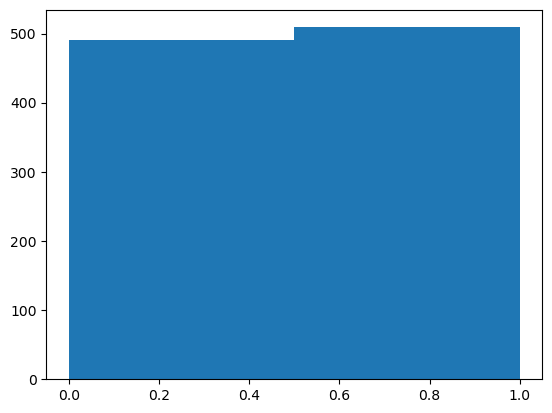

In [13]:
# (3) 1D array representing 1000 coin toss and histogram. 
coin_tosses = np.random.randint(0, 2, size=1000)
hist_vals = plt.hist(coin_tosses, bins=2) 

In [14]:
hist_vals

(array([491., 509.]), array([0. , 0.5, 1. ]), <a list of 2 Patch objects>)

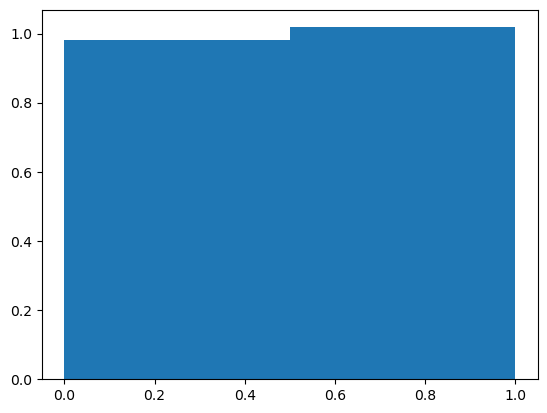

In [15]:
# If you want to get normalised histogram
hist_vals = plt.hist(coin_tosses, bins=2, density=True) 

Text(0, 0.5, 'Number of occurences')

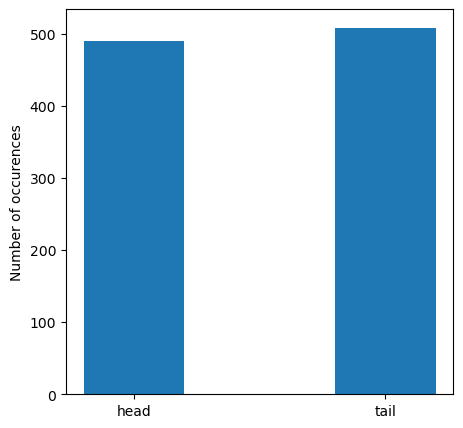

In [16]:
# To make a slightly nicer histogram 
f, ax = plt.subplots(figsize=(5,5))
hist_vals = ax.hist(coin_tosses, bins=2, align='mid', rwidth=0.4) # see the help of hist for details 
ax.set_xticks([0.25, 0.75])
ax.set_xticklabels(['head', 'tail'])
ax.set_ylabel('Number of occurences')

In [17]:
# (4) Fix the seed of your random generator. Create an array `a` of 10 integers between 0 and 10. 
# Redo this operation and save it into an array `b`. Compare `a` and `b`. 
np.random.seed(10)
a = np.random.randint(5, size=4)
b = np.random.randint(5, size=4)
a, b 

(array([1, 4, 0, 1]), array([3, 4, 1, 0]))

In [18]:
#np.random.seed?

In [19]:
# The officially cleaner way to proceed (cf help of np.seed)
# The behaviour is not the one I expect ... not sure why
#rs = np.random.RandomState(np.random.MT19937(np.random.SeedSequence(10)))
#a = rs.randint(5, size=4)
#b = rs.randint(5, size=4)
#a, b 

In [20]:
#How should you proceed to have 2 identical arrays ?  
#How should you proceed to have 2 identical arrays ?  
# If we want a and b to be identical we need to reseed before each new operation
np.random.seed(10)
a = np.random.randint(5, size=4)
np.random.seed(10)
b = np.random.randint(5, size=4)
a, b 

(array([1, 4, 0, 1]), array([1, 4, 0, 1]))

### I.3 What is a conditional probability $p(A | B)$ and Bayes theorem? 

The conditional probability expresses the fact that the probability of an event can depend on another one. For example, you may wonder what is the probability to have a flu if you have fever. You would write it $p(\rm{flu} | \rm{fever}) $, which reads "p of flu GIVEN fever". $p(A \, | \, B) = \frac{p(A \, \cap \, B)}{p(B)}$ is the *fraction of times* $A$ occurs when $B$ occurs.

The Bayes theorem expresses formally how to calculate this conditional probability:
$$
p(A\,|\,B) = \frac{p(B\,|\,A) \, p(A)}{p(B)}
$$

The main thing you have to recall with conditional probability is that $p(A | B) \neq p( B | A)$: probability to have a flu given you have fever is different from probability you have fever given you have a flu. 

**Question:**  Let's consider a rare disease that affects 0.1\% of the population. On the other hand, let's consider a test that is efficient at 99\% (i.e. 1 \% False positive rate). If you have a positive test, what is the probability for you to be affected by this disease ?   

Among 1000 persons, 1 has the disease (it touches 0.1 \% of the population). The test has 99% efficiency. Which means that 1% of the people will be tested positive while not being sick. => 10 people will be positive while healthy. You should add ~1 being positive while being effectively sick.     
=> $p(\rm{disease} | +) \sim 1/11 = 9\%$  

In [21]:
# What you are interested in is the p(disease | positive test)  
# p(d | +) = p(+ | d) * p(d) / p(+)
# We have p(+ | d) = 0.99 
p_B_given_A = 0.99
# We have probability of disease p(d) = 0.001 
p_A = 0.001
# We have probability of positive test = p(+ | d) * p (d) + p(+ | !d) * p(!d)
p_B = 0.001 *0.99 + (1.-0.001) * (1 - 0.99) 
p_A_given_B = p_B_given_A * p_A / p_B
p_A_given_B

0.09016393442622944

An alternative way to solve the problem is to fill the following table (aka **Contingency Table**) with the information in hand. 

|             | H = Disease        |  !H = No Disease     | Sum     |
| --------------| ---------------------| ----------------------| -------------------| 
| E = Test +   | $p(E|H)$ $\times$ $p(H)$ |  $p(E|!H)$ $\times$ $p(!H)$ | p($E$) |  
| !E = Test - | $p(!E|H)$ $\times$ $p(H)$| $p(!E|!H)$ $\times$ $p(!H)$ | p($!E$)|   
| Sum | $p(H)$  | $p(!H)$ | 1 | 

Let's do the calculation for a population of $n = 100000$ people. 


|        | Disease         | No Disease       | Sum          |
|--------| ----------------| -----------------| -------------| 
| Test + | 100 $\times$ 0.99 = 99| 99900 $\times$ (1-0.99) = 999 | $p(+)$ $\times \, n$ = 1098   | 
| Test - | 100 $\times$ (1-0.99) = 1 | 99900 - 999 = 98901 | $p(-)$ $\times \, n$ = 98902 | 
| Sum    | **100** $= p(d) \times n$ | **99900** = $p(!d) \times n$ | **n = 100000** | 


One can start filling this table with the bold number which express here the prior on getting the disease, which we consider being the probability of getting the disease (You may consider modifying this prior if, for example, you want to calculate the probability of someone who has already been tested positive to be positive). Then, you can start to fill each column multiplying by the efficiency of your test (p($+ | d$)) or its complement (2nd row). You can also do it only for the first row and derive the second row as being the third row (total prior weighted population) minus the second row. 


=> **Be careful with RARE events !** If you build an algorithm that detects securely 99% of the rare events (e.g. a gravitational lens, a supernova, a planet around a red dwarf, ...), you may still spend a lot of time observing false positives ... As a rule of thumb, when you design an algorithm that aims at finding rare objects, **you should aim for a False Positive Rate (FPR) at least smaller or equal than the prevalence of the event**. 

**The follow-up notebook is [Basic-statistics_01_Part1b.ipynb](Basic-statistics_01_Part1b.ipynb)**. It reviews the concepts of PDF and CDF and how to calculate them for specific distributions in python. 